In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("OnlineRetail.csv", encoding='ISO-8859-1')

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [6]:
df = df.dropna(subset=['CustomerID'])

In [7]:
df = df[df['Quantity'] > 0]

In [8]:
df = df[df['UnitPrice'] > 0]

In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [10]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [11]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.month

In [12]:
df['InvoiceYear'] = df['InvoiceDate'].dt.year

In [13]:
df['InvoiceDay'] = df['InvoiceDate'].dt.day_name()

In [14]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceMonth,InvoiceYear,InvoiceDay
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,2010,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,2010,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,2010,Wednesday


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   InvoiceNo     397884 non-null  object        
 1   StockCode     397884 non-null  object        
 2   Description   397884 non-null  object        
 3   Quantity      397884 non-null  int64         
 4   InvoiceDate   397884 non-null  datetime64[ns]
 5   UnitPrice     397884 non-null  float64       
 6   CustomerID    397884 non-null  float64       
 7   Country       397884 non-null  object        
 8   TotalPrice    397884 non-null  float64       
 9   InvoiceMonth  397884 non-null  int32         
 10  InvoiceYear   397884 non-null  int32         
 11  InvoiceDay    397884 non-null  object        
dtypes: datetime64[ns](1), float64(3), int32(2), int64(1), object(5)
memory usage: 36.4+ MB


In [16]:
df.shape

(397884, 12)

In [17]:
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_countries

,TotalPrice
Country,
United Kingdom,7308391.554
Netherlands,285446.340
EIRE,265545.900
Germany,228867.140
France,209024.050
Australia,138521.310
Spain,61577.110
Switzerland,56443.950
Belgium,41196.340


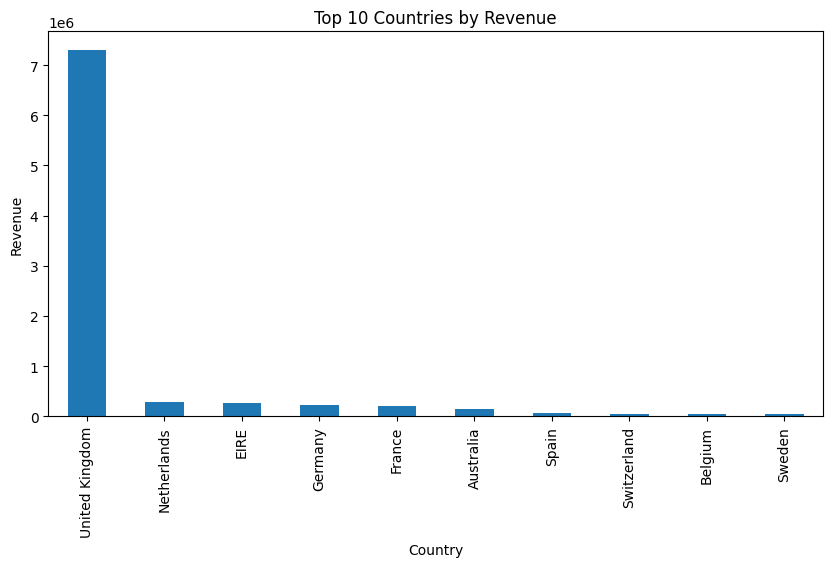

In [18]:
import matplotlib.pyplot as plt

top_countries.plot(kind='bar', figsize=(10,5))

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')

plt.show()

In [19]:
monthly_sales = df.groupby(['InvoiceYear','InvoiceMonth'])['TotalPrice'].sum()

monthly_sales

InvoiceYear  InvoiceMonth
2010         12               572713.890
2011         1                569445.040
             2                447137.350
             3                595500.760
             4                469200.361
             5                678594.560
             6                661213.690
             7                600091.011
             8                645343.900
             9                952838.382
             10              1039318.790
             11              1161817.380
             12               518192.790
Name: TotalPrice, dtype: float64

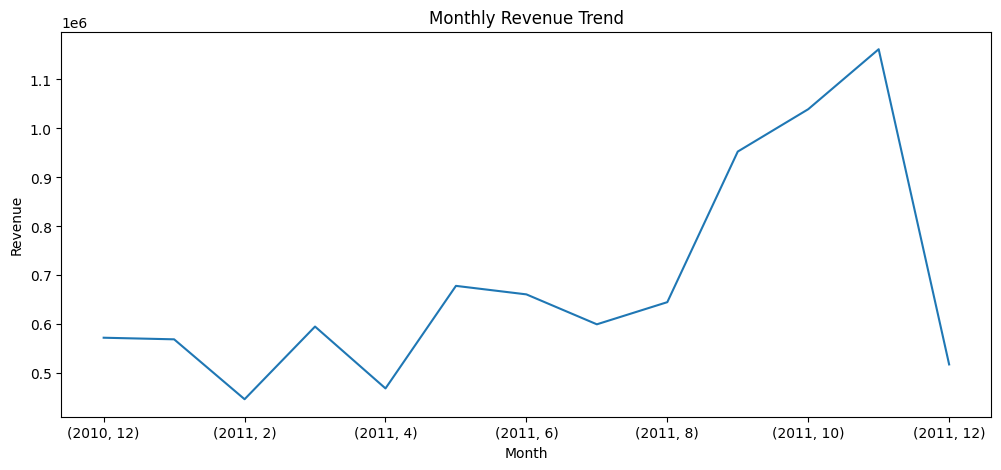

In [20]:
monthly_sales.plot(figsize=(12,5))

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

In [21]:
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_products

,TotalPrice
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142592.95
WHITE HANGING HEART T-LIGHT HOLDER,100448.15
JUMBO BAG RED RETROSPOT,85220.78
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68844.33
ASSORTED COLOUR BIRD ORNAMENT,56580.34
Manual,53779.93


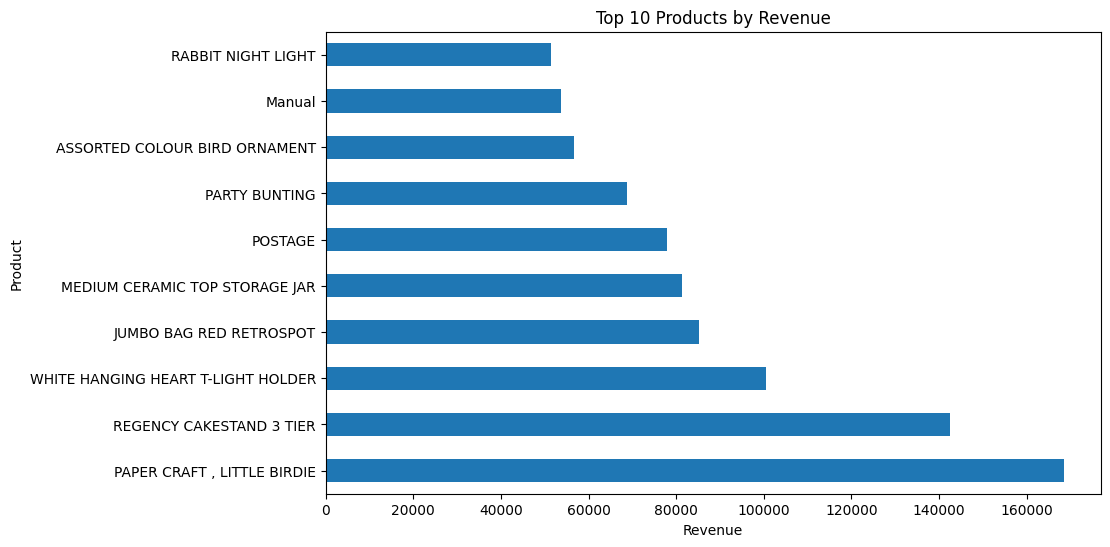

In [22]:
top_products.plot(kind='barh', figsize=(10,6))

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')

plt.show()

In [23]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_customers

,TotalPrice
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194550.79
16446.0,168472.50
14911.0,143825.06
12415.0,124914.53
14156.0,117379.63
17511.0,91062.38
16029.0,81024.84


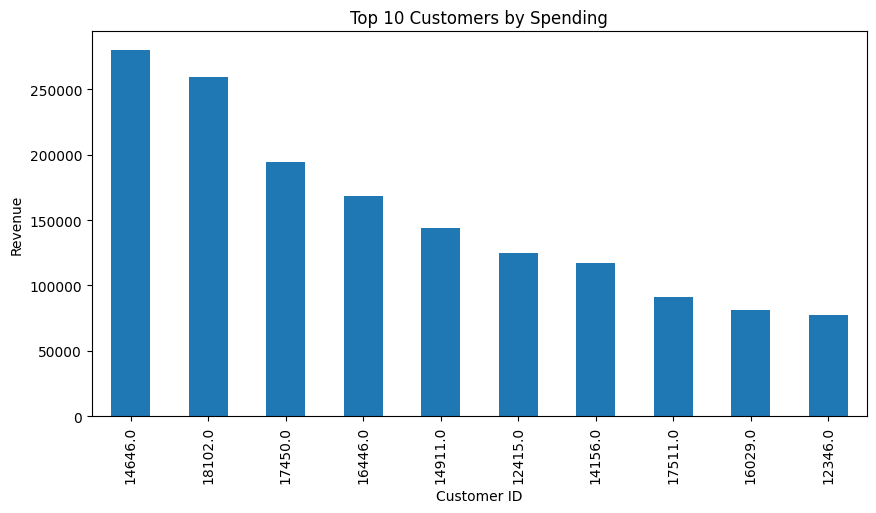

In [24]:
top_customers.plot(kind='bar', figsize=(10,5))

plt.title('Top 10 Customers by Spending')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')

plt.show()

In [25]:
sales_day = df.groupby('InvoiceDay')['TotalPrice'].sum().sort_values(ascending=False)

sales_day

,TotalPrice
InvoiceDay,
Thursday,1976859.070
Tuesday,1700634.631
Wednesday,1588336.170
Friday,1485917.401
Monday,1367146.411
Sunday,792514.221


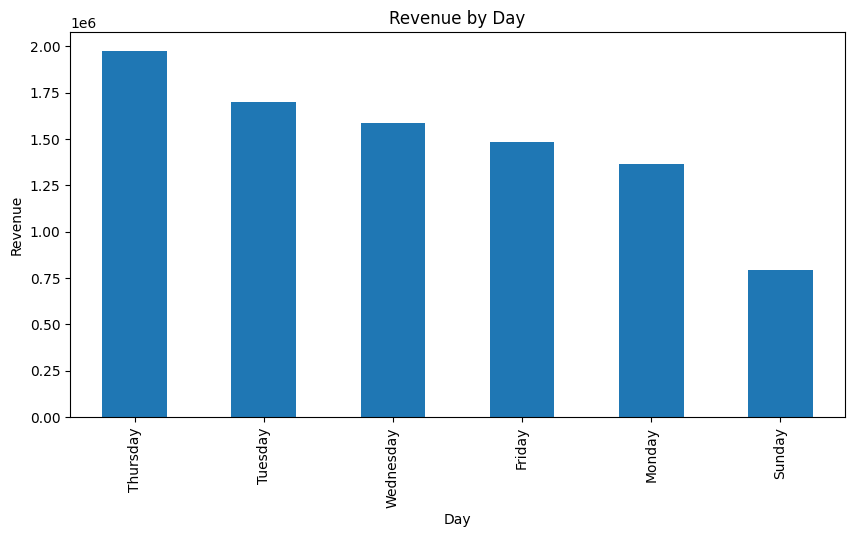

In [26]:
sales_day.plot(kind='bar', figsize=(10,5))

plt.title('Revenue by Day')
plt.xlabel('Day')
plt.ylabel('Revenue')

plt.show()

In [27]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [28]:
rfm = df.groupby('CustomerID').agg({

    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,

    'InvoiceNo': 'nunique',

    'TotalPrice': 'sum'
})

rfm

,InvoiceDate,InvoiceNo,TotalPrice
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
...,...,...,...
18280.0,278,1,180.60
18281.0,181,1,80.82
18282.0,8,2,178.05


In [29]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [30]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [31]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])

In [32]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

In [33]:
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

In [34]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


In [35]:
def customer_segment(row):

    if row['RFM_Score'] == '444':
        return 'VIP Customers'

    elif row['R_Score'] == 4:
        return 'Loyal Customers'

    elif row['F_Score'] == 4:
        return 'Frequent Customers'

    elif row['M_Score'] == 4:
        return 'Big Spenders'

    else:
        return 'Regular Customers'

In [36]:
rfm['Segment'] = rfm.apply(customer_segment, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,Big Spenders
12347.0,2,7,4310.00,4,4,4,444,VIP Customers
12348.0,75,4,1797.24,2,3,4,234,Big Spenders
12349.0,19,1,1757.55,3,1,4,314,Big Spenders
12350.0,310,1,334.40,1,1,2,112,Regular Customers


In [37]:
rfm['Segment'].value_counts()

,count
Segment,
Regular Customers,2532
Loyal Customers,635
VIP Customers,490
Frequent Customers,476
Big Spenders,205


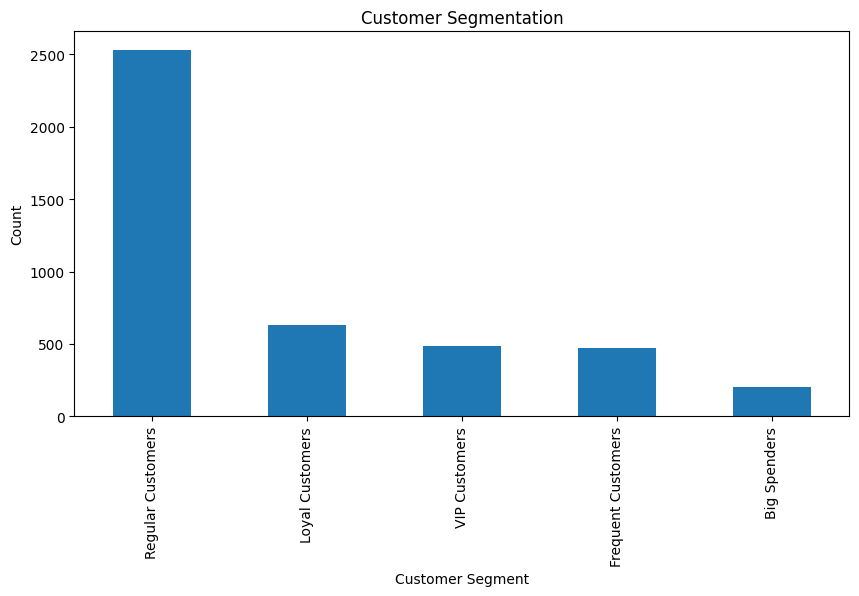

In [38]:
rfm['Segment'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Customer Segmentation')
plt.xlabel('Customer Segment')
plt.ylabel('Count')

plt.show()